In [1]:
#import all necessary libraries 
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
#data importing 
df = pd.read_csv(r"C:\Users\sahil\Downloads\archive (1)\stock_data.csv", parse_dates=[0])
df = df.set_index(df.columns[0])           # date as index
df.index.name = 'Date'


# Date becomes row labels.

# Why:-
# Because this is time-series data.
# Stock prediction needs date as index.

In [3]:
df.head(4)

,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5
Date,,,,,
2020-01-01,101.764052,100.160928,99.494642,99.909756,101.761266
2020-01-02,102.171269,99.969968,98.682973,100.640755,102.528643
2020-01-03,103.171258,99.575237,98.182139,100.574847,101.887811
2020-01-04,105.483215,99.308641,97.149381,100.925017,101.490049


In [4]:
# We'll predict Stock_1 
target = 'Stock_1'
data = df[[target]].copy()

In [5]:
#Feature engineering
for lag in [1, 3, 5, 7]:
    data[f'lag_{lag}'] = data[target].shift(lag)

data['rolling_mean_5']  = data[target].rolling(5).mean()
data['rolling_std_5']   = data[target].rolling(5).std()
data['price_diff_1']    = data[target].diff(1)

In [6]:
#Remove NAN value 
data = data.dropna()

In [7]:
X = data.drop(columns=[target])
y = data[target]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 286, Test size: 72


In [9]:
#Create Model
rf = RandomForestRegressor(random_state=42)

In [10]:
#Hyperparameter Tuning

param_dist = {
    'n_estimators':     [50, 100, 200, 300, 400],
    'max_depth':        [None, 5, 10, 15, 20],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features':     ['auto', 'sqrt', 0.8]
}

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,      
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [None, 5, 10, 15, 20],
                                        'max_features': ['auto', 'sqrt', 0.8],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 200, 300,
                                                         400]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=1)

In [11]:
print("\nBest parameters:")
print(random_search.best_params_)
print(f"Best CV RMSE: {np.sqrt(-random_search.best_score_):.4f}")

best_model = random_search.best_estimator_


Best parameters:
{'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.8, 'max_depth': None}
Best CV RMSE: 1.6465


In [12]:
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"\nTest RMSE: {rmse:.4f}")
print(f"Test R²:   {r2:.4f}")


Test RMSE: 2.0772
Test R²:   0.8024


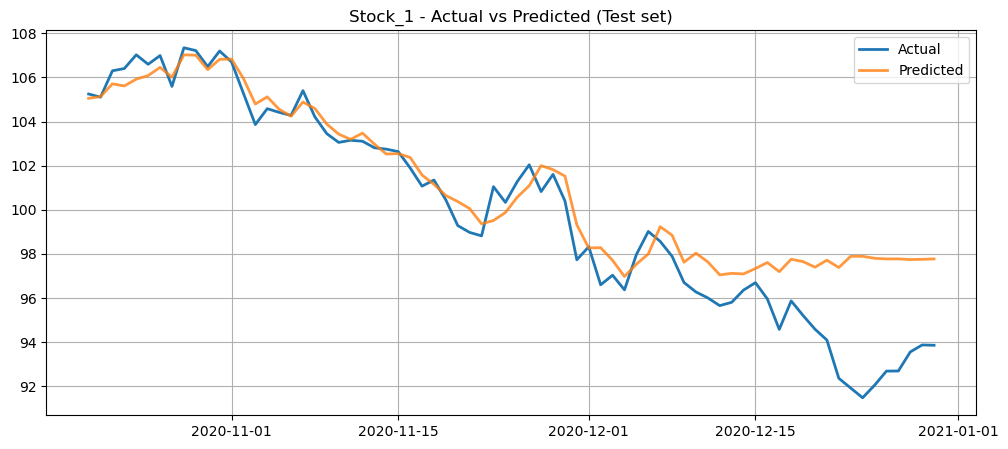

In [13]:
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label='Actual', linewidth=2)
plt.plot(y_test.index, y_pred, label='Predicted', linewidth=2, alpha=0.8)
plt.title(f'{target} - Actual vs Predicted (Test set)')
plt.legend()
plt.grid(True)
plt.show()